# 4.2 统计学基础

> **NOAI竞赛课程 · 模块四：数学基础（第3-4课时）**

---

## 本节目标

1. 描述统计量：均值、中位数、众数、分位数
2. 残差（Residual）的定义与计算
3. 偏差（Bias）的概念
4. 标准差与方差
5. 相关系数与协方差
6. Python实战：统计分析与可视化

---

## 一、描述统计量

### 1.1 均值（Mean）

$$\bar{x} = \frac{1}{n}\sum_{i=1}^{n} x_i$$

受极端值影响大。

### 1.2 中位数（Median）

排序后中间位置的值，对极端值鲁棒。

### 1.3 众数（Mode）

出现频率最高的值。

### 1.4 分位数与四分位距（IQR）

- $Q_1$（25%）、$Q_2$（50%=中位数）、$Q_3$（75%）
- $\text{IQR} = Q_3 - Q_1$
- 离群值：$< Q_1 - 1.5 \times \text{IQR}$ 或 $> Q_3 + 1.5 \times \text{IQR}$

In [10]:
import numpy as np
scores = np.array([72, 85, 90, 78, 95, 88, 76, 82, 91, 87, 89, 93, 77, 84, 86, 100])

print("=== 描述统计量 ===")
print(f"均值 = {scores.mean():.2f}")
print(f"中位数 = {np.median(scores):.2f}")
print(f"标准差 = {scores.std():.2f}")
print(f"方差 = {scores.var():.2f}")
print(f"Q1={np.percentile(scores,25):.1f}, Q2={np.percentile(scores,50):.1f}, Q3={np.percentile(scores,75):.1f}")

# 极端值影响
s2 = np.append(scores, 0)
print(f"\n加入0分后: 均值={s2.mean():.2f}(降{abs(scores.mean()-s2.mean()):.1f}), 中位数={np.median(s2):.2f}(仅降{abs(np.median(scores)-np.median(s2)):.1f})")

=== 描述统计量 ===
均值 = 85.81
中位数 = 86.50
标准差 = 7.26
方差 = 52.65
Q1=81.0, Q2=86.5, Q3=90.2

加入0分后: 均值=80.76(降5.0), 中位数=86.00(仅降0.5)


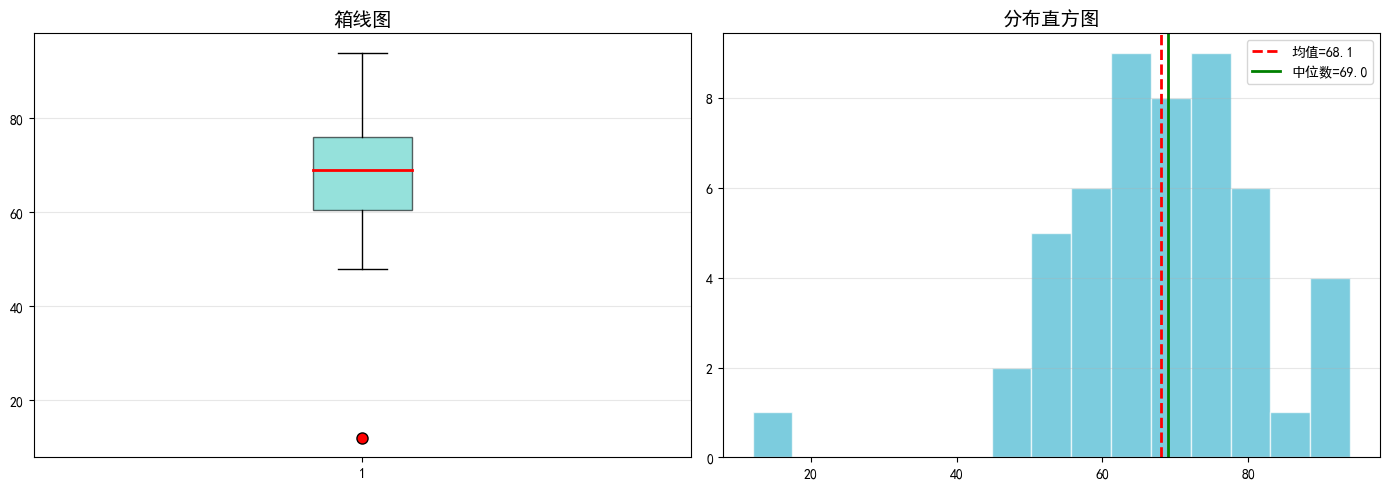

In [11]:
import matplotlib.pyplot as plt
# 设置支持中文的字体（如 SimHei 或 Microsoft YaHei）
plt.rcParams['font.sans-serif'] = ['SimHei', 'Microsoft YaHei']  # 优先使用SimHei，无则用微软雅黑
plt.rcParams['axes.unicode_minus'] = False  # 正确显示负号

np.random.seed(42)
data = np.random.normal(72, 12, 50).clip(0,100).round().astype(int)
data = np.append(data, [12])

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
bp = axes[0].boxplot(data, patch_artist=True,
    boxprops=dict(facecolor='#4ECDC4', alpha=0.6),
    medianprops=dict(color='red', lw=2),
    flierprops=dict(marker='o', markerfacecolor='red', ms=8))
axes[0].set_title('箱线图', fontweight='bold', fontsize=14)
axes[0].grid(alpha=0.3, axis='y')

axes[1].hist(data, bins=15, color='#45B7D1', alpha=0.7, edgecolor='white')
axes[1].axvline(data.mean(), color='red', ls='--', lw=2, label=f'均值={data.mean():.1f}')
axes[1].axvline(np.median(data), color='green', ls='-', lw=2, label=f'中位数={np.median(data):.1f}')
axes[1].set_title('分布直方图', fontweight='bold', fontsize=14)
axes[1].legend(); axes[1].grid(alpha=0.3, axis='y')
plt.tight_layout(); plt.show()

---

## 二、残差（Residual）

$$e_i = y_i - \hat{y}_i$$

| $e_i$ | 含义 |
|--------|------|
| $e_i > 0$ | 模型低估 |
| $e_i < 0$ | 模型高估 |

**误差指标**：MSE $= \frac{1}{n}\sum e_i^2$，RMSE $= \sqrt{\text{MSE}}$，MAE $= \frac{1}{n}\sum|e_i|$

In [12]:
x = np.array([1,2,3,4,5,6,7,8], dtype=float)
y_act = np.array([4,5,7,10,11,13,15,17], dtype=float)
y_pred = 2.0*x + 1.0
residuals = y_act - y_pred

print("=== 残差计算 ===")
for i in range(len(x)):
    meaning = "低估" if residuals[i] > 0 else "高估" if residuals[i] < 0 else "完美"
    print(f"  x={int(x[i])}: 实际={y_act[i]:.0f}, 预测={y_pred[i]:.0f}, 残差={residuals[i]:+.0f} ({meaning})")
print(f"\nMSE={np.mean(residuals**2):.3f}, RMSE={np.sqrt(np.mean(residuals**2)):.3f}, MAE={np.mean(np.abs(residuals)):.3f}")

=== 残差计算 ===
  x=1: 实际=4, 预测=3, 残差=+1 (低估)
  x=2: 实际=5, 预测=5, 残差=+0 (完美)
  x=3: 实际=7, 预测=7, 残差=+0 (完美)
  x=4: 实际=10, 预测=9, 残差=+1 (低估)
  x=5: 实际=11, 预测=11, 残差=+0 (完美)
  x=6: 实际=13, 预测=13, 残差=+0 (完美)
  x=7: 实际=15, 预测=15, 残差=+0 (完美)
  x=8: 实际=17, 预测=17, 残差=+0 (完美)

MSE=0.250, RMSE=0.500, MAE=0.250


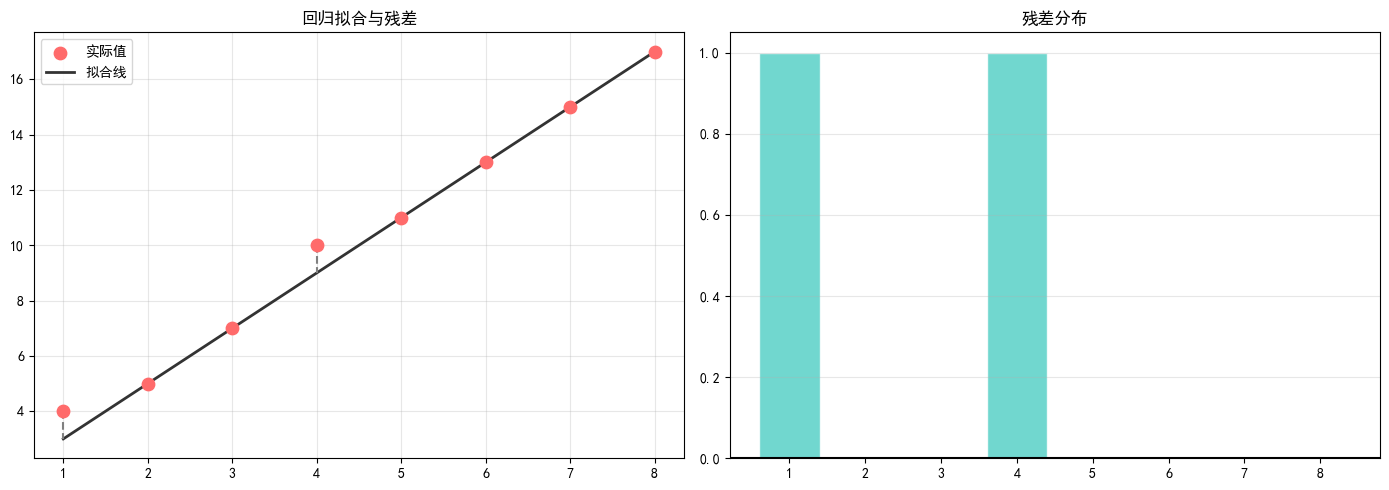

In [13]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].scatter(x, y_act, color='#FF6B6B', s=80, zorder=5, label='实际值')
axes[0].plot(x, y_pred, color='#333', lw=2, label='拟合线')
for xi, yi, pi in zip(x, y_act, y_pred):
    axes[0].plot([xi,xi], [yi,pi], 'gray', lw=1.5, ls='--')
axes[0].set_title('回归拟合与残差', fontweight='bold'); axes[0].legend(); axes[0].grid(alpha=0.3)

colors = ['#4ECDC4' if r>=0 else '#FF6B6B' for r in residuals]
axes[1].bar(x, residuals, color=colors, alpha=0.8, edgecolor='white')
axes[1].axhline(0, color='black', lw=1.5)
axes[1].set_title('残差分布', fontweight='bold'); axes[1].grid(alpha=0.3, axis='y')
plt.tight_layout(); plt.show()

---

## 三、偏差（Bias）

### 3.1 统计偏差

$$\text{Bias}(\hat{\theta}) = E[\hat{\theta}] - \theta$$

**Bessel校正**：
- 有偏方差 $s^2 = \frac{1}{n}\sum(x_i-\bar{x})^2$
- 无偏方差 $s^2 = \frac{1}{n-1}\sum(x_i-\bar{x})^2$

### 3.2 偏差-方差权衡

$$\text{总误差} = \text{偏差}^2 + \text{方差} + \text{噪声}$$

| | 高偏差（欠拟合） | 高方差（过拟合） |
|---|---|---|
| 表现 | 训练/测试误差都高 | 训练低，测试高 |
| 解决 | 增加复杂度 | 正则化/增加数据 |

In [14]:
np.random.seed(42)
true_var = 100
biased_vars, unbiased_vars = [], []
for _ in range(10000):
    s = np.random.normal(50, 10, 10)
    biased_vars.append(np.var(s, ddof=0))
    unbiased_vars.append(np.var(s, ddof=1))

print("=== 偏差验证：有偏 vs 无偏方差 ===")
print(f"真实方差 = {true_var}")
print(f"有偏(ddof=0) 均值 = {np.mean(biased_vars):.2f} (偏差={np.mean(biased_vars)-true_var:.2f})")
print(f"无偏(ddof=1) 均值 = {np.mean(unbiased_vars):.2f} (偏差={np.mean(unbiased_vars)-true_var:.2f})")
print("\n➜ Bessel校正(n-1)消除了系统偏差！")

=== 偏差验证：有偏 vs 无偏方差 ===
真实方差 = 100
有偏(ddof=0) 均值 = 89.83 (偏差=-10.17)
无偏(ddof=1) 均值 = 99.81 (偏差=-0.19)

➜ Bessel校正(n-1)消除了系统偏差！


C:\Users\Terry\AppData\Local\Temp\ipykernel_11812\1894917698.py:15: UserWarning: Glyph 178 (\N{SUPERSCRIPT TWO}) missing from current font.
  plt.tight_layout(); plt.show()
c:\ProgramData\Anaconda3\envs\py311\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 178 (\N{SUPERSCRIPT TWO}) missing from current font.
  fig.canvas.print_figure(bytes_io, **kw)


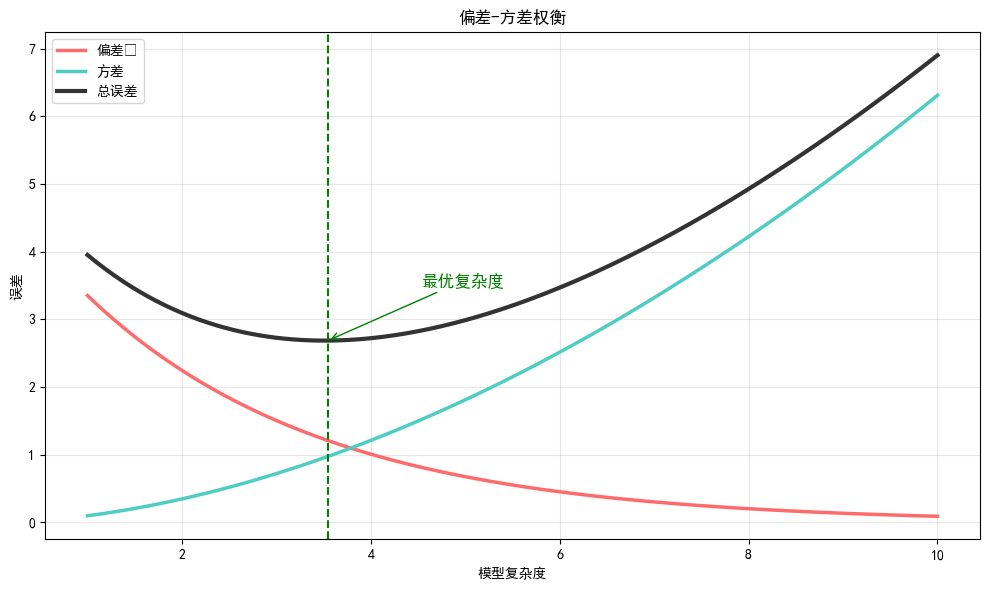

In [15]:
fig, ax = plt.subplots(figsize=(10, 6))
c = np.linspace(1, 10, 100)
bias_sq = 5.0 * np.exp(-0.4*c)
variance = 0.1 * c**1.8
total = bias_sq + variance + 0.5
ax.plot(c, bias_sq, '#FF6B6B', lw=2.5, label='偏差²')
ax.plot(c, variance, '#4ECDC4', lw=2.5, label='方差')
ax.plot(c, total, '#333', lw=3, label='总误差')
opt = np.argmin(total)
ax.axvline(c[opt], color='green', ls='--')
ax.annotate('最优复杂度', (c[opt], total[opt]), xytext=(c[opt]+1, total[opt]+0.8),
    arrowprops=dict(arrowstyle='->', color='green'), fontsize=12, color='green')
ax.set_xlabel('模型复杂度'); ax.set_ylabel('误差')
ax.set_title('偏差-方差权衡', fontweight='bold'); ax.legend(); ax.grid(alpha=0.3)
plt.tight_layout(); plt.show()

---

## 四、标准差与方差

$$\text{Var}(X) = \sigma^2 = \frac{1}{n}\sum(x_i-\bar{x})^2, \quad \sigma = \sqrt{\text{Var}(X)}$$

In [16]:
A = np.array([85,86,84,87,83,86,85,84,86,84])
B = np.array([95,75,90,80,85,70,100,65,88,92])
print(f"班级A: 均值={A.mean():.0f}, 方差={A.var():.2f}, 标准差={A.std():.2f}")
print(f"班级B: 均值={B.mean():.0f}, 方差={B.var():.2f}, 标准差={B.std():.2f}")
print(f"\n➜ 两班均值接近，但B的离散程度远大于A")

班级A: 均值=85, 方差=1.40, 标准差=1.18
班级B: 均值=84, 方差=114.80, 标准差=10.71

➜ 两班均值接近，但B的离散程度远大于A


---

## 五、相关系数与协方差

### 协方差

$$\text{Cov}(X,Y) = \frac{1}{n-1}\sum(x_i-\bar{x})(y_i-\bar{y})$$

### Pearson相关系数

$$r = \frac{\text{Cov}(X,Y)}{\sigma_X \cdot \sigma_Y} \in [-1, 1]$$

| $|r|$ | 相关程度 |
|------|----------|
| 0~0.3 | 弱 |
| 0.3~0.7 | 中 |
| 0.7~1.0 | 强 |

⚠️ $r=0$ 只表示无线性关系，可能有非线性关系！

In [17]:
hours = np.array([2,3,4,5,6,7,8,9,10,11], dtype=float)
scores = np.array([50,55,60,65,70,72,80,85,90,95], dtype=float)

print(f"协方差 = {np.cov(hours, scores)[0,1]:.2f}")
print(f"相关系数 r = {np.corrcoef(hours, scores)[0,1]:.3f}")
print(f"➜ 学习时间与成绩强正相关")

# 非线性关系示例
x = np.array([-3,-2,-1,0,1,2,3], dtype=float)
y = x**2
print(f"\ny=x²时, r = {np.corrcoef(x,y)[0,1]:.3f} (实际有完美非线性关系！)")

协方差 = 45.67
相关系数 r = 0.998
➜ 学习时间与成绩强正相关

y=x²时, r = 0.000 (实际有完美非线性关系！)


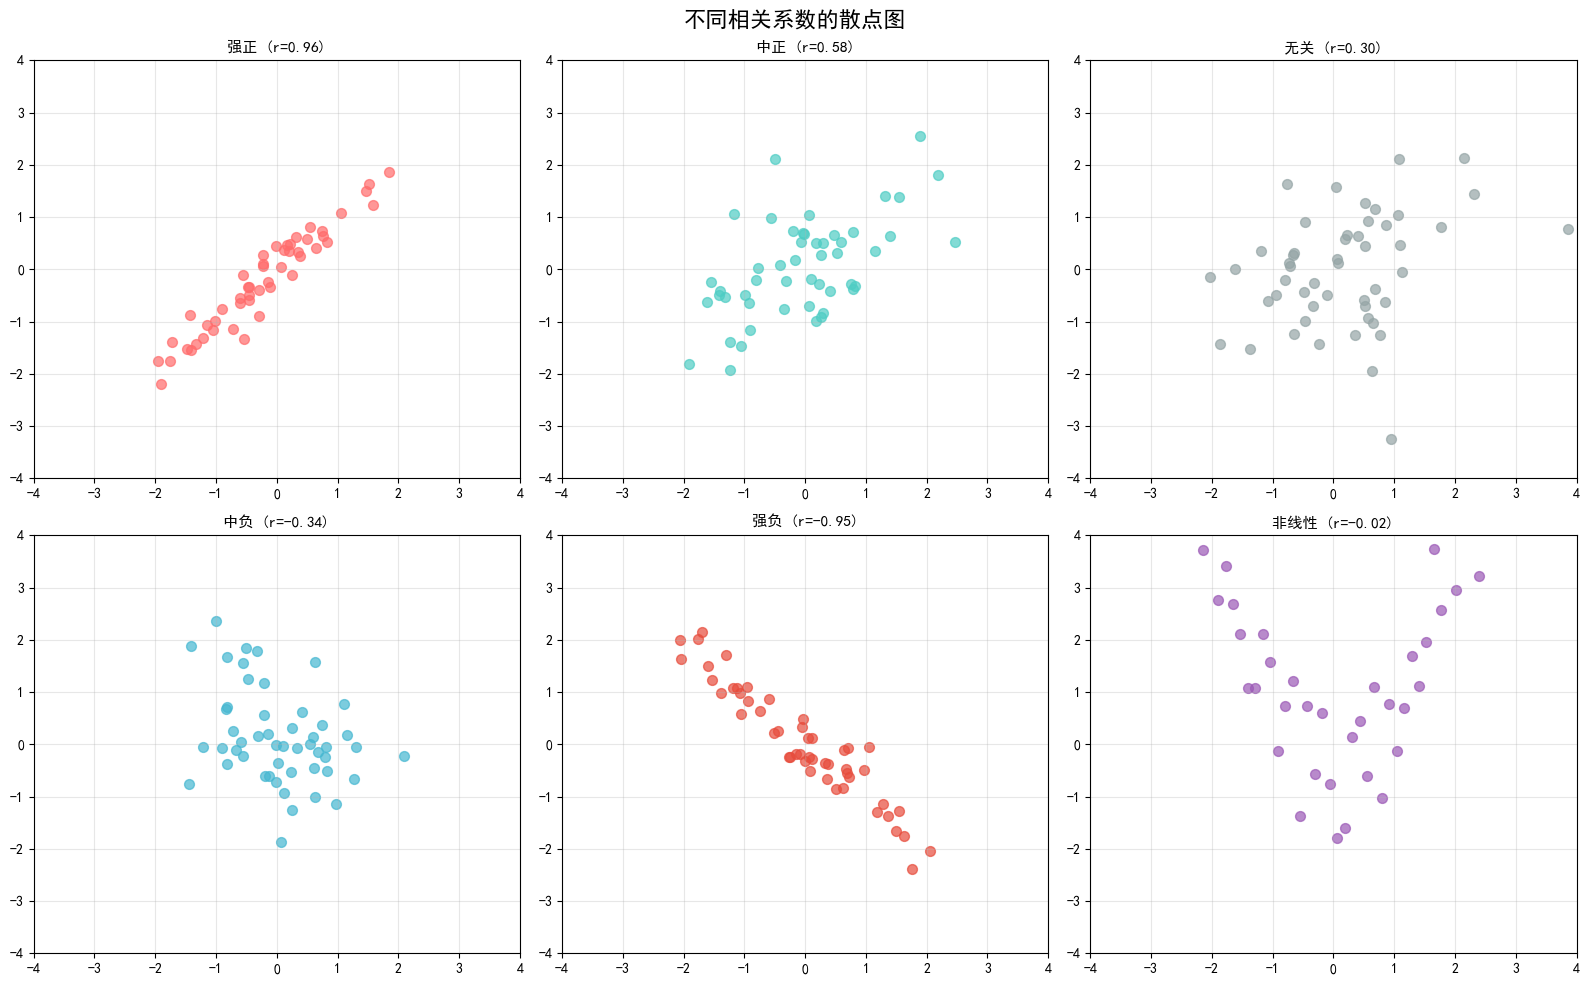

In [18]:
fig, axes = plt.subplots(2, 3, figsize=(16, 10))
np.random.seed(42)
examples = [(0.95,'强正','#FF6B6B'),(0.5,'中正','#4ECDC4'),(0.0,'无关','#95a5a6'),
             (-0.5,'中负','#45B7D1'),(-0.95,'强负','#e74c3c'),(None,'非线性','#9b59b6')]
for ax, (tr, title, color) in zip(axes.flat, examples):
    if tr is None:
        x = np.linspace(-3,3,50); y = x**2 + np.random.normal(0,1,50)
    else:
        x = np.random.normal(0,1,50); y = tr*x + np.sqrt(1-tr**2)*np.random.normal(0,1,50)
    ax.scatter(x, y, color=color, alpha=0.7, s=50)
    r = np.corrcoef(x,y)[0,1]
    ax.set_title(f'{title} (r={r:.2f})', fontweight='bold', fontsize=11)
    ax.grid(alpha=0.3); ax.set_xlim(-4,4); ax.set_ylim(-4,4)
plt.suptitle('不同相关系数的散点图', fontweight='bold', fontsize=16); plt.tight_layout(); plt.show()

---

## 📌 本节要点

1. **均值**易受极端值影响，**中位数**更鲁棒
2. **残差** = 实际值 - 预测值，MSE/RMSE/MAE是评估指标
3. **Bessel校正** (n-1) 消除方差估计偏差
4. **偏差-方差权衡**是ML核心：简单模型高偏差，复杂模型高方差
5. **相关系数** r∈[-1,1] 衡量线性相关，r=0不代表无关

🚀 **下一节**：[4.3 距离度量](./4.3_距离度量.ipynb)